# PDPTW + Max Ride Time

The intro PDPTW notebook (`05_pdptw_walkthrough.ipynb`) showed 5 requests + 2 vehicles + pickup-delivery pairing. This one cranks up two dials:

1. **Bigger instance** — 12 requests, 5 vehicles, capacity 5 each. Closer to a realistic last-mile or dial-a-ride scenario.
2. **Max ride time per request** — once a parcel is picked up, it must be delivered within `max_ride` minutes. The constraint says "don't leave freight sitting in the truck for hours."

Max ride time is the dial-a-ride world's most important constraint. It models:

- **Ride-share / paratransit:** passengers can't be held captive in a detour.
- **Same-day delivery:** sender/receiver SLAs.
- **Perishables:** the cold chain has a half-life.

## New OR-Tools API

Just one line per request, added to the model after the pair constraints:

```python
routing.solver().Add(
    time_dim.CumulVar(d_idx) - time_dim.CumulVar(p_idx) <= max_ride[request]
)
```

It's an arithmetic constraint on the *Time* dimension. The CumulVar at a pickup is the arrival time at that pickup; at a delivery, the arrival time at the delivery. Their difference is the elapsed time on board. Bound that by `max_ride` and the solver will refuse any route where the constraint is violated.

In [1]:
%load_ext autoreload
%autoreload 2

import math
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from ortools.constraint_solver import pywrapcp, routing_enums_pb2

random.seed(73)
np.random.seed(73)

## 1. A larger instance

- 12 pickup-delivery requests scattered through a 60×60 km area.
- 5 vehicles, capacity 5 each.
- 8-hour working day (480 min), 5-min service per stop.
- Pickup windows 90 min wide, randomly placed in the morning/early afternoon.
- Delivery windows 180 min wide, starting where the pickup window ends.
- Per-request demand 1–2 units.

We'll also annotate each request with its **natural ride time** — the minimum possible time between pickup and delivery (= travel time + service time). The `max_ride` parameter has to be at least this; anything tighter is infeasible by construction.

In [2]:
N_REQUESTS = 12
DEPOT = 0
HORIZON = 480
SERVICE_TIME = 5
NUM_VEHICLES = 5
VEHICLE_CAPACITY = 5

points = [(30.0, 30.0)]
demands = [0]
windows = [(0, HORIZON)]
labels = ["depot"]
pairs = []
quantities = []

for i in range(N_REQUESTS):
    p = (random.uniform(2, 58), random.uniform(2, 58))
    d = (random.uniform(2, 58), random.uniform(2, 58))
    q = random.randint(1, 2)
    pickup_start = random.randint(30, 270)

    points.append(p)
    demands.append(+q)
    windows.append((pickup_start, pickup_start + 90))
    labels.append(f"P{i}")
    pickup_node = len(points) - 1

    points.append(d)
    demands.append(-q)
    delivery_start = pickup_start + 90
    windows.append((delivery_start, delivery_start + 180))
    labels.append(f"D{i}")
    delivery_node = len(points) - 1

    pairs.append((pickup_node, delivery_node))
    quantities.append(q)


def make_int_distance(pts):
    n = len(pts)
    m = [[0] * n for _ in range(n)]
    for i, (xi, yi) in enumerate(pts):
        for j, (xj, yj) in enumerate(pts):
            if i != j:
                m[i][j] = int(round(math.hypot(xi - xj, yi - yj)))
    return m

distance = make_int_distance(points)

# Natural (minimum) ride time per request = service + travel from pickup to delivery.
natural_ride = [SERVICE_TIME + distance[p][d] for p, d in pairs]

summary = pd.DataFrame({
    "request": list(range(N_REQUESTS)),
    "q": quantities,
    "pickup_window": [windows[p] for p, _ in pairs],
    "delivery_window": [windows[d] for _, d in pairs],
    "natural_ride_min": natural_ride,
})
print(f"Total freight: {sum(quantities)} units, fleet capacity: {NUM_VEHICLES * VEHICLE_CAPACITY}")
print(f"Natural ride times: min={min(natural_ride)}, max={max(natural_ride)}, median={int(np.median(natural_ride))}")
summary

Total freight: 17 units, fleet capacity: 25
Natural ride times: min=11, max=55, median=27


,request,q,pickup_window,delivery_window,natural_ride_min
0,0,1,"(154, 244)","(244, 424)",21
1,1,2,"(229, 319)","(319, 499)",32
2,2,2,"(76, 166)","(166, 346)",22
3,3,1,"(148, 238)","(238, 418)",49
4,4,1,"(85, 175)","(175, 355)",32
5,5,1,"(159, 249)","(249, 429)",11
6,6,1,"(196, 286)","(286, 466)",16
7,7,2,"(238, 328)","(328, 508)",55
8,8,2,"(57, 147)","(147, 327)",14
9,9,1,"(122, 212)","(212, 392)",51


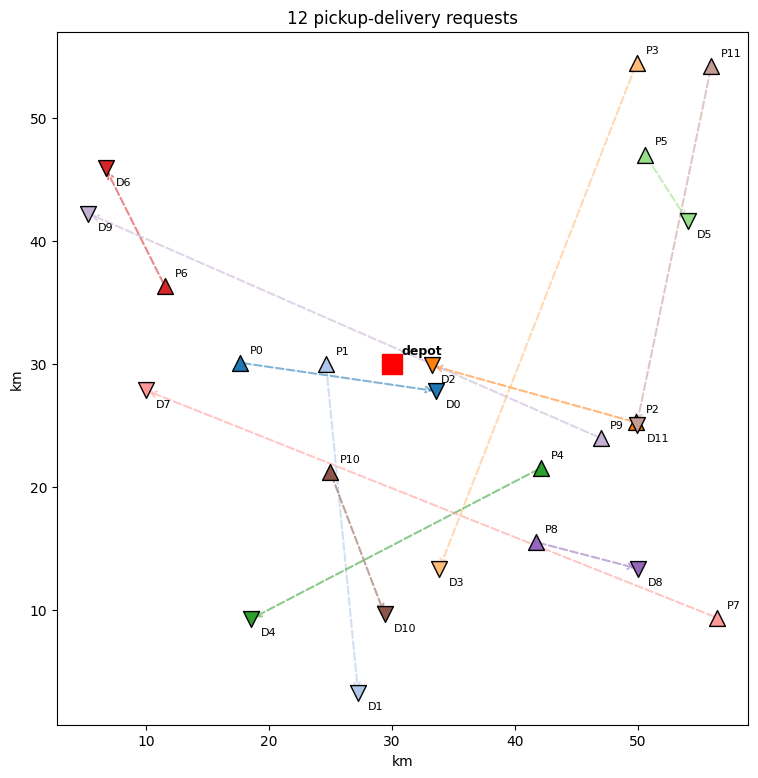

In [3]:
def plot_instance(points, pairs, labels):
    fig, ax = plt.subplots(figsize=(9, 9))
    request_colors = plt.cm.tab20(np.linspace(0, 1, max(20, len(pairs))))
    for i, (pn, dn) in enumerate(pairs):
        ax.annotate("", xy=points[dn], xytext=points[pn],
                    arrowprops=dict(arrowstyle="->", color=request_colors[i],
                                    lw=1.5, linestyle="dashed", alpha=0.55))
        ax.scatter(*points[pn], marker="^", s=130, color=request_colors[i],
                   edgecolors="black", zorder=5)
        ax.scatter(*points[dn], marker="v", s=130, color=request_colors[i],
                   edgecolors="black", zorder=5)
        ax.annotate(labels[pn], points[pn], textcoords="offset points",
                    xytext=(7, 7), fontsize=8)
        ax.annotate(labels[dn], points[dn], textcoords="offset points",
                    xytext=(7, -12), fontsize=8)
    ax.scatter(*points[0], c="red", s=220, marker="s", zorder=6)
    ax.annotate("depot", points[0], textcoords="offset points",
                xytext=(7, 7), fontsize=9, fontweight="bold")
    ax.set_aspect("equal")
    ax.set_xlabel("km"); ax.set_ylabel("km")
    ax.set_title(f"{len(pairs)} pickup-delivery requests")
    plt.show()

plot_instance(points, pairs, labels)

## 2. Model builder with optional max-ride

Same skeleton as PDPTW. The single addition is the `max_ride_time` argument and a per-pair constraint loop at the end. `max_ride_time` can be:

- `None` — no constraint, equivalent to the basic PDPTW.
- An `int` — same maximum applied to every request (uniform SLA).
- A sequence — per-request maximum, indexed the same as `pairs`.

In [4]:
def build_pdptw(
    distance, demands, time_windows, pairs, capacities,
    service_time, horizon, depot=0, wait_slack=60, max_ride_time=None,
):
    n = len(distance)
    num_vehicles = len(capacities)
    manager = pywrapcp.RoutingIndexManager(n, num_vehicles, depot)
    routing = pywrapcp.RoutingModel(manager)

    def distance_cb(fi, ti):
        return distance[manager.IndexToNode(fi)][manager.IndexToNode(ti)]
    transit_idx = routing.RegisterTransitCallback(distance_cb)
    routing.SetArcCostEvaluatorOfAllVehicles(transit_idx)

    def demand_cb(fi):
        return demands[manager.IndexToNode(fi)]
    demand_idx = routing.RegisterUnaryTransitCallback(demand_cb)
    routing.AddDimensionWithVehicleCapacity(
        demand_idx, 0, list(capacities), True, "Capacity",
    )

    def time_cb(fi, ti):
        from_node = manager.IndexToNode(fi)
        to_node = manager.IndexToNode(ti)
        st = 0 if from_node == depot else service_time
        return st + distance[from_node][to_node]
    time_idx = routing.RegisterTransitCallback(time_cb)
    routing.AddDimension(time_idx, wait_slack, horizon, False, "Time")
    time_dim = routing.GetDimensionOrDie("Time")

    for node in range(n):
        if node == depot:
            continue
        a, b = time_windows[node]
        time_dim.CumulVar(manager.NodeToIndex(node)).SetRange(int(a), int(b))

    depot_open, depot_close = time_windows[depot]
    for v in range(num_vehicles):
        time_dim.CumulVar(routing.Start(v)).SetRange(int(depot_open), int(depot_close))
        time_dim.CumulVar(routing.End(v)).SetRange(int(depot_open), int(depot_close))
        routing.AddVariableMinimizedByFinalizer(time_dim.CumulVar(routing.Start(v)))
        routing.AddVariableMinimizedByFinalizer(time_dim.CumulVar(routing.End(v)))

    # Normalise max_ride_time to a per-request list (or None to skip).
    if max_ride_time is None:
        ride_limits = None
    elif isinstance(max_ride_time, int):
        ride_limits = [max_ride_time] * len(pairs)
    else:
        ride_limits = list(max_ride_time)

    for i, (pickup_node, delivery_node) in enumerate(pairs):
        p_idx = manager.NodeToIndex(pickup_node)
        d_idx = manager.NodeToIndex(delivery_node)
        routing.AddPickupAndDelivery(p_idx, d_idx)
        routing.solver().Add(routing.VehicleVar(p_idx) == routing.VehicleVar(d_idx))
        routing.solver().Add(time_dim.CumulVar(p_idx) <= time_dim.CumulVar(d_idx))
        if ride_limits is not None:
            routing.solver().Add(
                time_dim.CumulVar(d_idx) - time_dim.CumulVar(p_idx) <= ride_limits[i]
            )

    return manager, routing, time_dim


def solve(routing, time_limit=15):
    params = pywrapcp.DefaultRoutingSearchParameters()
    params.first_solution_strategy = routing_enums_pb2.FirstSolutionStrategy.PARALLEL_CHEAPEST_INSERTION
    params.local_search_metaheuristic = routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH
    params.time_limit.FromSeconds(time_limit)
    return routing.SolveWithParameters(params)


## 3. Baseline: no max-ride

Solve the instance with everything *except* the max-ride constraint. This tells us how the solver naturally consolidates work — and gives a baseline distance to measure overhead against.

In [5]:
def solve_and_summarise(max_ride_time=None, time_limit=15):
    mgr, rt, tdim = build_pdptw(
        distance, demands, windows, pairs,
        capacities=[VEHICLE_CAPACITY] * NUM_VEHICLES,
        service_time=SERVICE_TIME, horizon=HORIZON,
        max_ride_time=max_ride_time,
    )
    sol = solve(rt, time_limit=time_limit)
    if sol is None:
        return None, None, None, rt.status()

    routes = []
    ride_times = []
    used = 0
    for v in range(NUM_VEHICLES):
        idx = rt.Start(v)
        route = []
        while not rt.IsEnd(idx):
            route.append(mgr.IndexToNode(idx))
            idx = sol.Value(rt.NextVar(idx))
        route.append(mgr.IndexToNode(idx))
        routes.append(route)
        if len(route) > 2:
            used += 1

    for p_node, d_node in pairs:
        p_idx = mgr.NodeToIndex(p_node)
        d_idx = mgr.NodeToIndex(d_node)
        ride_times.append(sol.Min(tdim.CumulVar(d_idx)) - sol.Min(tdim.CumulVar(p_idx)))

    return {
        "obj": sol.ObjectiveValue(),
        "vehicles_used": used,
        "max_ride_seen": max(ride_times),
        "median_ride": int(np.median(ride_times)),
    }, routes, ride_times, rt.status()


baseline, baseline_routes, baseline_rides, status = solve_and_summarise(max_ride_time=None)
print(f"Baseline (no max-ride): status={status}")
for k, v in baseline.items():
    print(f"  {k}: {v}")
print("\nPer-request ride times (minutes):")
print(pd.DataFrame({"request": range(N_REQUESTS),
                    "natural": natural_ride,
                    "actual": baseline_rides,
                    "overhead": [b - n for b, n in zip(baseline_rides, natural_ride)]}))

Baseline (no max-ride): status=1
  obj: 357
  vehicles_used: 2
  max_ride_seen: 257
  median_ride: 85

Per-request ride times (minutes):
    request  natural  actual  overhead
0         0       21     140       119
1         1       32     116        84
2         2       22      28         6
3         3       49     173       124
4         4       32     257       225
5         5       11      71        60
6         6       16      31        15
7         7       55      74        19
8         8       14      74        60
9         9       51      97        46
10       10       17      35        18
11       11       35     146       111


The `overhead` column = actual ride − natural ride. Anything > 0 means the solver chose to keep that parcel on the truck longer than strictly necessary, presumably because it could chain another pickup or delivery on the way. That overhead is exactly what max-ride limits.

## 4. Sweeping max-ride

Now constrain max-ride. We'll sweep from generous to tight and watch what happens to:

- **Total distance** (the objective)
- **Vehicles used** (tighter SLAs force more vehicles into service)
- **Max ride seen** (should drop to ≤ the constraint)
- **Solver status** (will eventually go infeasible)

In [6]:
rows = []
for mr in [None, 240, 180, 120, 90, 60, 45]:
    summary, _, _, status = solve_and_summarise(max_ride_time=mr, time_limit=10)
    rows.append({
        "max_ride": "none" if mr is None else mr,
        "status": status,
        "obj": summary["obj"] if summary else None,
        "vehicles_used": summary["vehicles_used"] if summary else None,
        "observed_max_ride": summary["max_ride_seen"] if summary else None,
        "median_ride": summary["median_ride"] if summary else None,
    })
sweep_df = pd.DataFrame(rows)
sweep_df

,max_ride,status,obj,vehicles_used,observed_max_ride,median_ride
0,none,1,357.0,2.0,257.0,85.0
1,240,1,368.0,2.0,240.0,88.0
2,180,1,373.0,2.0,180.0,120.0
3,120,1,425.0,3.0,120.0,85.0
4,90,1,425.0,3.0,90.0,90.0
5,60,1,497.0,3.0,60.0,59.0
6,45,3,NaN,NaN,NaN,NaN


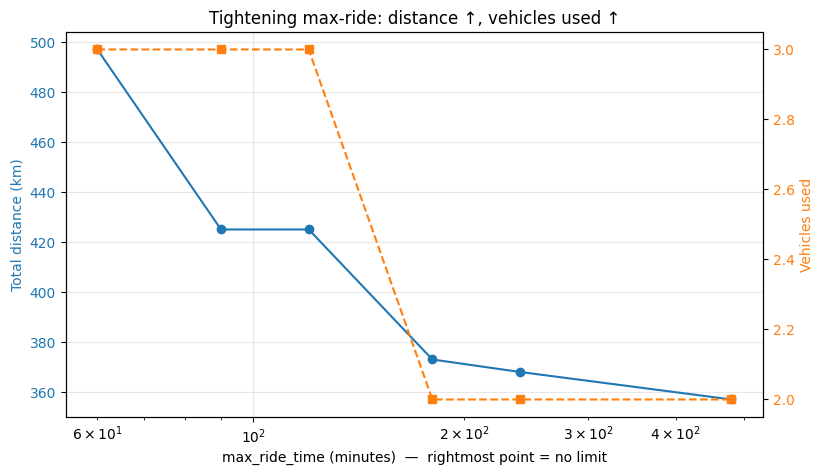

In [7]:
ok = sweep_df[sweep_df["obj"].notna()].copy()
if "none" in ok["max_ride"].values:
    # Replace 'none' with a number for plotting; use a value bigger than the natural max.
    ok["max_ride_plot"] = ok["max_ride"].replace("none", 480)
else:
    ok["max_ride_plot"] = ok["max_ride"]
ok["max_ride_plot"] = ok["max_ride_plot"].astype(int)
ok = ok.sort_values("max_ride_plot")

fig, ax1 = plt.subplots(figsize=(9, 5))
c1, c2 = "tab:blue", "tab:orange"
ax1.plot(ok["max_ride_plot"], ok["obj"], "o-", color=c1)
ax1.set_xlabel("max_ride_time (minutes)  —  rightmost point = no limit")
ax1.set_ylabel("Total distance (km)", color=c1)
ax1.tick_params(axis="y", labelcolor=c1)
ax1.grid(alpha=0.3)
ax1.set_xscale("log")

ax2 = ax1.twinx()
ax2.plot(ok["max_ride_plot"], ok["vehicles_used"], "s--", color=c2)
ax2.set_ylabel("Vehicles used", color=c2)
ax2.tick_params(axis="y", labelcolor=c2)

plt.title("Tightening max-ride: distance \u2191, vehicles used \u2191")
plt.show()

## 5. Two solutions side by side

Plot the baseline (no max-ride) next to a tight solution (max-ride = 90 min) on the same axes. The tight version should show more vehicles in play and routes that go pickup→delivery more directly, with less detour for opportunistic chaining.

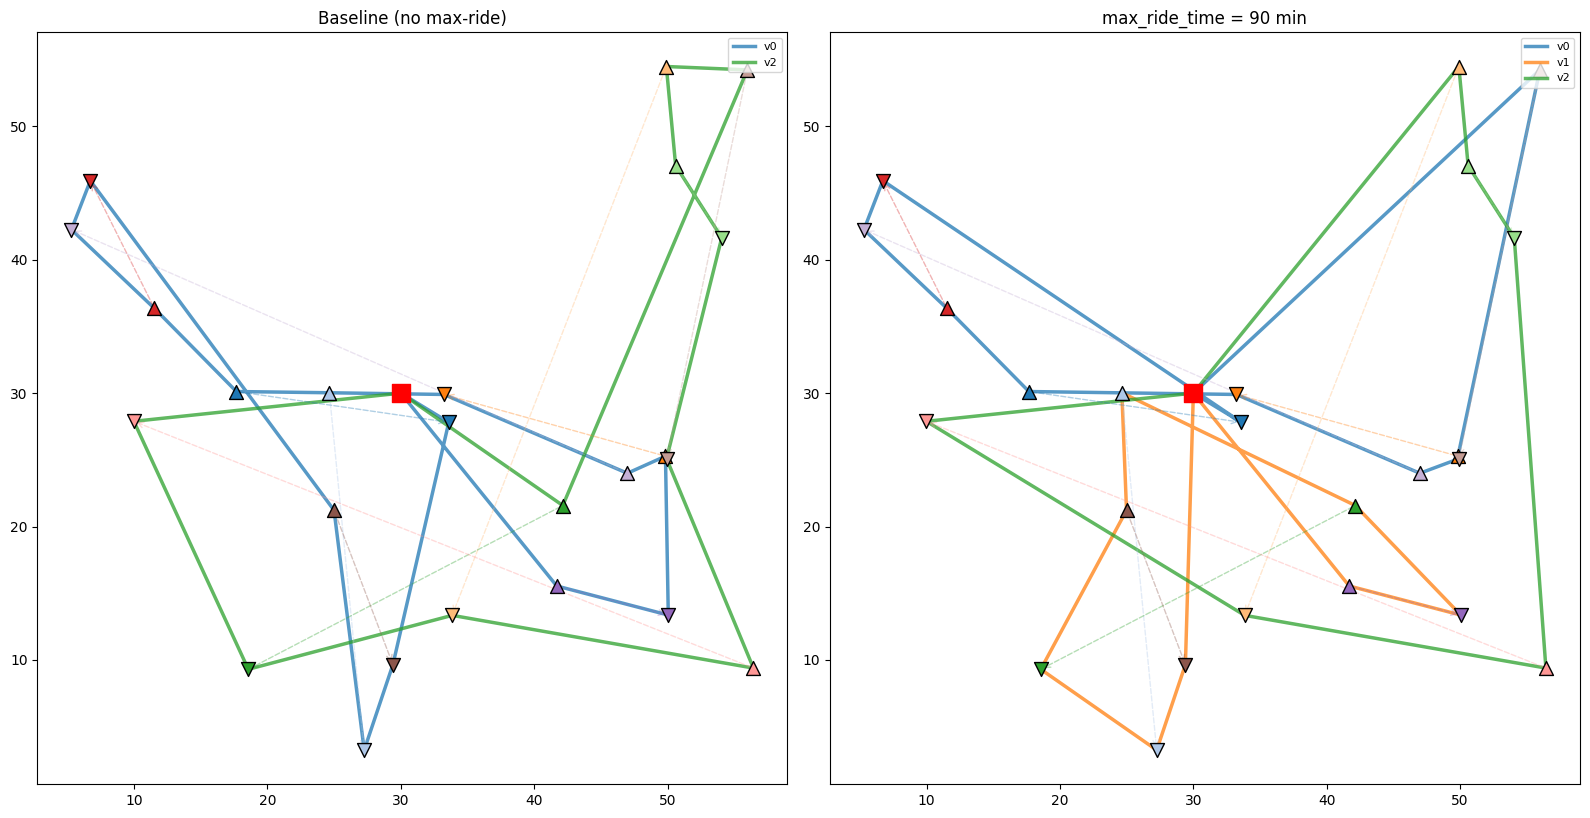

In [8]:
_, routes_tight, _, _ = solve_and_summarise(max_ride_time=90, time_limit=10)

def plot_routes_side(points, pairs, routes_a, routes_b, labels, title_a, title_b):
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    request_colors = plt.cm.tab20(np.linspace(0, 1, max(20, len(pairs))))
    vehicle_colors = plt.cm.tab10(np.linspace(0, 1, 10))
    for ax, routes, ttl in [(axes[0], routes_a, title_a), (axes[1], routes_b, title_b)]:
        for i, (pn, dn) in enumerate(pairs):
            ax.annotate("", xy=points[dn], xytext=points[pn],
                        arrowprops=dict(arrowstyle="->", color=request_colors[i],
                                        lw=1, linestyle="dashed", alpha=0.35))
        for v, r in enumerate(routes):
            if len(r) <= 2:
                continue
            rx = [points[i][0] for i in r]
            ry = [points[i][1] for i in r]
            ax.plot(rx, ry, "-", color=vehicle_colors[v % 10], lw=2.5, alpha=0.75,
                    label=f"v{v}")
        for i, (pn, dn) in enumerate(pairs):
            ax.scatter(*points[pn], marker="^", s=100, color=request_colors[i],
                       edgecolors="black", zorder=5)
            ax.scatter(*points[dn], marker="v", s=100, color=request_colors[i],
                       edgecolors="black", zorder=5)
        ax.scatter(*points[0], c="red", s=180, marker="s", zorder=6)
        ax.set_aspect("equal"); ax.set_title(ttl)
        ax.legend(loc="upper right", fontsize=8)
    plt.tight_layout(); plt.show()

plot_routes_side(points, pairs, baseline_routes, routes_tight, labels,
                 "Baseline (no max-ride)", "max_ride_time = 90 min")

## What's next

This is essentially the **dial-a-ride** model — bigger fleet, paired requests, time windows on both ends, ride-time cap. From here the natural moves are:

- **Per-request ride limits** (already supported via list to `max_ride_time`) — model different SLAs per customer.
- **Soft max-ride** (penalty above the cap, not hard constraint) — use `time_dim.SetCumulVarSoftUpperBound` on the *delivery* CumulVar relative to a derived quantity.
- **Real road network** — replace the Euclidean distance with `osmnx`-derived travel times.
- **Stochastic travel times** — Monte-Carlo over uncertainty.

## Promoting to `vrp_lib`

The next commit extends `vrp_lib.solve_pdptw` with a `max_ride_time` argument (accepting `None`, `int`, or per-request sequence) and adds a test that the constraint is actually respected.